In [22]:
!pip install -q tensorflow tensorflow-datasets


In [23]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


In [24]:
print(tf.__version__)


2.19.0


In [25]:
(ds_train, ds_val), ds_info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

print(ds_info)



tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

In [26]:
print(type(ds_train))


<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>


In [27]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [29]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


In [30]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dense(1, activation="sigmoid")(x)

model = Model(inputs, x)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)



Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 121s 175ms/step - accuracy: 0.5526 - loss: 0.6917 - val_accuracy: 0.5907 - val_loss: 0.6634
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 99s 168ms/step - accuracy: 0.5993 - loss: 0.6605 - val_accuracy: 0.6242 - val_loss: 0.6447
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 99s 168ms/step - accuracy: 0.6132 - loss: 0.6541 - val_accuracy: 0.6389 - val_loss: 0.6368
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 99s 168ms/step - accuracy: 0.6258 - loss: 0.6485 - val_accuracy: 0.6447 - val_loss: 0.6233
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 98s 167ms/step - accuracy: 0.6276 - loss: 0.6436 - val_accuracy: 0.6234 - val_loss: 0.6443


In [32]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 145s 224ms/step - accuracy: 0.6602 - loss: 0.6209 - val_accuracy: 0.6763 - val_loss: 0.6085
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 130s 220ms/step - accuracy: 0.7271 - loss: 0.5358 - val_accuracy: 0.7646 - val_loss: 0.4915
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 129s 220ms/step - accuracy: 0.7404 - loss: 0.5212 - val_accuracy: 0.7805 - val_loss: 0.4646
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 128s 218ms/step - accuracy: 0.7516 - loss: 0.5052 - val_accuracy: 0.6698 - val_loss: 0.6655
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 129s 219ms/step - accuracy: 0.7565 - loss: 0.4946 - val_accuracy: 0.7736 - val_loss: 0.4748


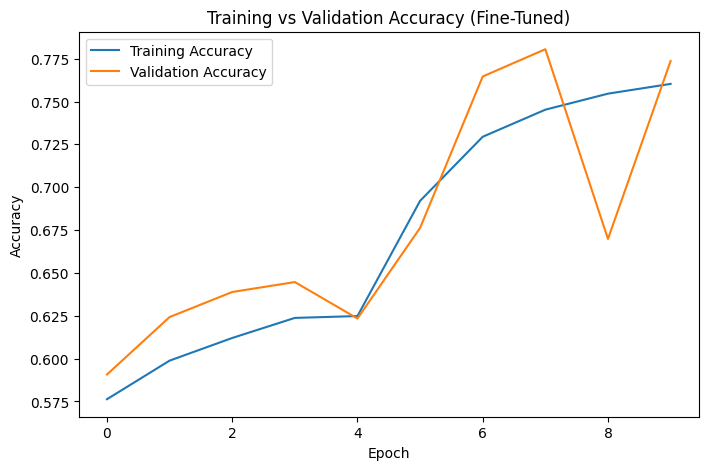

In [33]:
acc = history.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_finetune.history["val_accuracy"]

plt.figure(figsize=(8,5))
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Fine-Tuned)")
plt.legend()
plt.show()


In [34]:
model.save("resnet50_cats_vs_dogs_finetuned.h5")

